# TrafficIQ — Advanced Demand Prediction
**Goal:** Maximize `max(0, 100 × R²)` on the test set.  
**Strategy:** Smart imputation → rich feature engineering → XGBoost + LightGBM + CatBoost ensemble → K-fold validation → best submission.

## 0 · Setup

In [1]:
import subprocess, sys
for pkg in ['python-geohash', 'lightgbm', 'catboost']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import geohash as gh

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, early_stopping as lgb_early_stop, log_evaluation as lgb_log_eval
from catboost import CatBoostRegressor

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path('../data')
SUB_DIR  = Path('../submissions')
SUB_DIR.mkdir(exist_ok=True)

print('Libraries loaded ✓')


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


Libraries loaded ✓


## 1 · Load Data

In [2]:
train_raw = pd.read_csv(DATA_DIR / 'train.csv')
test_raw  = pd.read_csv(DATA_DIR / 'test.csv')

print(f'Train: {train_raw.shape}  |  Test: {test_raw.shape}')
train_raw.head(3)

Train: (77299, 11)  |  Test: (41778, 10)


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny


## 2 · Smart Data Cleaning
Rules applied in order:
1. Flag missing values **before** imputation (`_was_missing` columns)
2. RoadType → geohash mode, fallback overall mode
3. Temperature → geohash median → weather group median → overall median
4. Weather → geohash mode, fallback overall mode
5. All fill mappings learned from **train only**, applied to test

In [3]:
train = train_raw.copy()
test  = test_raw.copy()

missing_cols = ['RoadType', 'Temperature', 'Weather']

print('=== Missing counts BEFORE cleaning ===')
print(train[missing_cols].isnull().sum())

# ── was_missing flags ─────────────────────────────────────────────────────
for col in missing_cols:
    train[f'{col}_was_missing'] = train[col].isnull().astype(int)
    test[f'{col}_was_missing']  = test[col].isnull().astype(int)

# ── RoadType ──────────────────────────────────────────────────────────────
geo_roadtype    = (train.dropna(subset=['RoadType'])
                       .groupby('geohash')['RoadType']
                       .agg(lambda x: x.mode()[0]))
overall_roadtype = train['RoadType'].mode()[0]

def fill_roadtype(df):
    mask = df['RoadType'].isna()
    df.loc[mask, 'RoadType'] = df.loc[mask, 'geohash'].map(geo_roadtype).fillna(overall_roadtype)
    return df

train = fill_roadtype(train)
test  = fill_roadtype(test)

# ── Temperature ───────────────────────────────────────────────────────────
geo_temp     = train.groupby('geohash')['Temperature'].median()
weather_temp = train.groupby('Weather')['Temperature'].median()
overall_temp = train['Temperature'].median()

def fill_temperature(df):
    mask = df['Temperature'].isna()
    filled = df.loc[mask, 'geohash'].map(geo_temp)
    still  = filled.isna()
    filled.loc[still] = df.loc[mask[mask].index[still], 'Weather'].map(weather_temp)
    filled = filled.fillna(overall_temp)
    df.loc[mask, 'Temperature'] = filled.values
    return df

train = fill_temperature(train)
test  = fill_temperature(test)

# ── Weather ───────────────────────────────────────────────────────────────
geo_weather     = (train.dropna(subset=['Weather'])
                       .groupby('geohash')['Weather']
                       .agg(lambda x: x.mode()[0]))
overall_weather = train['Weather'].mode()[0]

def fill_weather(df):
    mask = df['Weather'].isna()
    df.loc[mask, 'Weather'] = df.loc[mask, 'geohash'].map(geo_weather).fillna(overall_weather)
    return df

train = fill_weather(train)
test  = fill_weather(test)

print('\n=== Missing counts AFTER cleaning (train) ===')
print(train[missing_cols].isnull().sum())
print('\n=== Missing counts AFTER cleaning (test) ===')
print(test[missing_cols].isnull().sum())

=== Missing counts BEFORE cleaning ===
RoadType        600
Temperature    2495
Weather         797
dtype: int64

=== Missing counts AFTER cleaning (train) ===
RoadType       0
Temperature    0
Weather        0
dtype: int64

=== Missing counts AFTER cleaning (test) ===
RoadType       0
Temperature    0
Weather        0
dtype: int64


## 3 · Feature Engineering
All aggregated stats (demand by geohash, time slot, etc.) are computed from **train only** and joined to both splits.

In [4]:
def add_time_features(df):
    parts = df['timestamp'].str.split(':', expand=True).astype(int)
    df['hour']       = parts[0]
    df['minute']     = parts[1]
    df['time_slot']  = df['hour'] * 4 + df['minute'] // 15   # 0-95
    df['hour_sin']   = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']   = np.cos(2 * np.pi * df['hour'] / 24)
    df['ts_sin']     = np.sin(2 * np.pi * df['time_slot'] / 96)
    df['ts_cos']     = np.cos(2 * np.pi * df['time_slot'] / 96)
    df['day_of_week']= df['day'] % 7
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['is_rush_hour']= df['hour'].isin([7,8,9,17,18,19]).astype(int)
    df['is_night']   = df['hour'].isin([22,23,0,1,2,3,4,5]).astype(int)

    def _period(h):
        if 6 <= h < 12:  return 0   # morning
        if 12 <= h < 17: return 1   # afternoon
        if 17 <= h < 21: return 2   # evening
        return 3                    # night
    df['time_period'] = df['hour'].apply(_period)
    return df

train = add_time_features(train)
test  = add_time_features(test)
print('Time features added ✓')

Time features added ✓


In [5]:
def decode_geo(code):
    try:
        lat, lon, _, _ = gh.decode_exactly(code)
        return lat, lon
    except Exception:
        return np.nan, np.nan

def add_location_features(df, center_lat, center_lon):
    coords = df['geohash'].apply(decode_geo)
    df['lat'] = coords.apply(lambda x: x[0])
    df['lon'] = coords.apply(lambda x: x[1])
    df['dist_center'] = np.sqrt((df['lat'] - center_lat)**2 + (df['lon'] - center_lon)**2)
    df['geo3'] = df['geohash'].str[:3]
    df['geo4'] = df['geohash'].str[:4]
    df['geo5'] = df['geohash'].str[:5]
    return df

# Compute center from train
train_coords = train['geohash'].apply(decode_geo)
center_lat = train_coords.apply(lambda x: x[0]).mean()
center_lon = train_coords.apply(lambda x: x[1]).mean()

train = add_location_features(train, center_lat, center_lon)
test  = add_location_features(test,  center_lat, center_lon)
print(f'Location features added ✓  (center: {center_lat:.4f}, {center_lon:.4f})')

Location features added ✓  (center: -5.3484, 90.7641)


In [6]:
# One-hot encode RoadType and Weather
train = pd.get_dummies(train, columns=['RoadType', 'Weather'], drop_first=False)
test  = pd.get_dummies(test,  columns=['RoadType', 'Weather'], drop_first=False)

# Align columns (test may be missing a category seen only in train)
for col in [c for c in train.columns if c.startswith('RoadType_') or c.startswith('Weather_')]:
    if col not in test.columns:
        test[col] = 0

train['has_large_vehicles'] = (train['LargeVehicles'] == 'Allowed').astype(int)
train['has_landmark']       = (train['Landmarks']     == 'Yes').astype(int)
test['has_large_vehicles']  = (test['LargeVehicles']  == 'Allowed').astype(int)
test['has_landmark']        = (test['Landmarks']      == 'Yes').astype(int)

print('Categorical encoding done ✓')

Categorical encoding done ✓


In [7]:
# ── Aggregated demand stats (train only) ───────────────────────────────────

# per geohash
geo_stats = train.groupby('geohash')['demand'].agg(
    geo_mean_demand='mean', geo_median_demand='median',
    geo_std_demand='std',   geo_max_demand='max'
).reset_index()

# per time_slot
ts_stats = train.groupby('time_slot')['demand'].agg(
    time_mean_demand='mean', time_median_demand='median'
).reset_index()

# road_time (RoadType_orig x time_slot)
train['_rt_orig'] = train_raw['RoadType'].fillna(overall_roadtype)
test['_rt_orig']  = test_raw['RoadType'].fillna(overall_roadtype) if 'RoadType' in test_raw.columns else overall_roadtype
# after clean, just re-derive from original column (already cleaned)
# We stored the cleaned RoadType in one-hot form; recover original label
rt_oh_cols = [c for c in train.columns if c.startswith('RoadType_') and c != 'RoadType_was_missing']
train['_rt_orig'] = train[rt_oh_cols].idxmax(axis=1).str.replace('RoadType_', '', regex=False)
test['_rt_orig']  = test[rt_oh_cols].idxmax(axis=1).str.replace('RoadType_', '', regex=False)

road_time = train.groupby(['_rt_orig', 'time_slot'])['demand'].mean().reset_index()
road_time.columns = ['_rt_orig', 'time_slot', 'road_time_demand']

# geo_time (geohash x hour)
geo_time = train.groupby(['geohash', 'hour'])['demand'].mean().reset_index()
geo_time.columns = ['geohash', 'hour', 'geo_time_demand']

# weather_demand
wth_oh_cols = [c for c in train.columns if c.startswith('Weather_') and c != 'Weather_was_missing']
train['_wth_orig'] = train[wth_oh_cols].idxmax(axis=1).str.replace('Weather_', '', regex=False)
test['_wth_orig']  = test[wth_oh_cols].idxmax(axis=1).str.replace('Weather_', '', regex=False)
weather_dem = train.groupby('_wth_orig')['demand'].mean().reset_index()
weather_dem.columns = ['_wth_orig', 'weather_demand']

# day_demand
day_dem = train.groupby('day')['demand'].mean().reset_index()
day_dem.columns = ['day', 'day_demand']

def join_agg_stats(df):
    df = df.merge(geo_stats,   on='geohash',              how='left')
    df = df.merge(ts_stats,    on='time_slot',            how='left')
    df = df.merge(road_time,   on=['_rt_orig', 'time_slot'], how='left')
    df = df.merge(geo_time,    on=['geohash', 'hour'],    how='left')
    df = df.merge(weather_dem, on='_wth_orig',            how='left')
    df = df.merge(day_dem,     on='day',                  how='left')
    df.drop(columns=['_rt_orig', '_wth_orig'], inplace=True, errors='ignore')
    return df

train = join_agg_stats(train)
test  = join_agg_stats(test)
print('Aggregated demand stats joined ✓')

Aggregated demand stats joined ✓


In [8]:
# Interaction features
for df in [train, test]:
    df['temp_x_lanes']       = df['Temperature'] * df['NumberofLanes']
    df['rush_x_lanes']       = df['is_rush_hour'] * df['NumberofLanes']
    df['weekend_x_landmark'] = df['is_weekend']   * df['has_landmark']

# Geohash prefix label encoding
for col in ['geo3', 'geo4', 'geo5', 'geohash']:
    le = LabelEncoder()
    le.fit(train[col].astype(str))
    enc_col = col + '_enc'
    known   = set(le.classes_)
    train[enc_col] = le.transform(train[col].astype(str))
    test[enc_col]  = test[col].astype(str).map(
        lambda x: le.transform([x])[0] if x in known else -1
    )

print('Interaction features + geo encoding done ✓')

Interaction features + geo encoding done ✓


## 4 · Build Feature Matrix

In [9]:
DROP = {'Index', 'geohash', 'timestamp', 'LargeVehicles', 'Landmarks',
        'geo3', 'geo4', 'geo5', 'demand'}

numeric_dtypes = {np.float64, np.int64, np.int32, np.float32, np.uint8, bool}
feature_cols = [
    c for c in train.columns
    if c not in DROP and train[c].dtype.type in {np.float64, np.int64, np.int32,
                                                  np.float32, np.uint8, np.bool_}
]

# Ensure test has the same columns
for col in feature_cols:
    if col not in test.columns:
        test[col] = 0

X      = train[feature_cols].fillna(0)
y      = train['demand']
X_test = test[feature_cols].fillna(0)

print(f'Feature matrix X:      {X.shape}')
print(f'Feature matrix X_test: {X_test.shape}')
print(f'Total features:        {len(feature_cols)}')

Feature matrix X:      (77299, 47)
Feature matrix X_test: (41778, 47)
Total features:        47


In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'Train split: {X_train.shape}  |  Val split: {X_val.shape}')

Train split: (61839, 47)  |  Val split: (15460, 47)


## 5 · Train & Compare 3 Models

### Model A — XGBoost (tuned)

In [11]:
print('=' * 55)
print('Training XGBoost...')
print('=' * 55)

xgb_model = XGBRegressor(
    n_estimators=1000, max_depth=7, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='rmse'
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

xgb_pred_val = xgb_model.predict(X_val)
xgb_r2       = r2_score(y_val, xgb_pred_val)
print(f'\nXGBoost  Val R²: {xgb_r2:.4f}  |  Score: {max(0, 100*xgb_r2):.2f}')

Training XGBoost...
[0]	validation_0-rmse:0.13814


[100]	validation_0-rmse:0.02592


[200]	validation_0-rmse:0.02481


[300]	validation_0-rmse:0.02481


[305]	validation_0-rmse:0.02481



XGBoost  Val R²: 0.9696  |  Score: 96.96


### Model B — LightGBM (tuned)

In [12]:
print('=' * 55)
print('Training LightGBM...')
print('=' * 55)

lgb_model = LGBMRegressor(
    n_estimators=1000, max_depth=-1, num_leaves=63,
    learning_rate=0.03, subsample=0.8, colsample_bytree=0.8,
    min_child_samples=20, reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb_early_stop(50), lgb_log_eval(100)]
)

lgb_pred_val = lgb_model.predict(X_val)
lgb_r2       = r2_score(y_val, lgb_pred_val)
print(f'\nLightGBM  Val R²: {lgb_r2:.4f}  |  Score: {max(0, 100*lgb_r2):.2f}')

Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002000 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3235
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 46
[LightGBM] [Info] Start training from score 0.093784
Training until validation scores don't improve for 50 rounds


[100]	valid_0's l2: 0.000618855


[200]	valid_0's l2: 0.000540404


[300]	valid_0's l2: 0.000530182


[400]	valid_0's l2: 0.000527884


[500]	valid_0's l2: 0.000526743


Early stopping, best iteration is:
[480]	valid_0's l2: 0.000526546

LightGBM  Val R²: 0.9740  |  Score: 97.40


### Model C — CatBoost (tuned)

In [13]:
print('=' * 55)
print('Training CatBoost...')
print('=' * 55)

cat_model = CatBoostRegressor(
    iterations=1000, depth=7, learning_rate=0.03,
    l2_leaf_reg=3, random_seed=SEED, verbose=100,
    early_stopping_rounds=50
)
cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val)
)

cat_pred_val = cat_model.predict(X_val)
cat_r2       = r2_score(y_val, cat_pred_val)
print(f'\nCatBoost  Val R²: {cat_r2:.4f}  |  Score: {max(0, 100*cat_r2):.2f}')

Training CatBoost...
0:	learn: 0.1383185	test: 0.1383586	best: 0.1383586 (0)	total: 60.8ms	remaining: 1m


100:	learn: 0.0254184	test: 0.0262482	best: 0.0262482 (100)	total: 336ms	remaining: 2.99s


200:	learn: 0.0228490	test: 0.0241681	best: 0.0241681 (200)	total: 608ms	remaining: 2.42s


300:	learn: 0.0221594	test: 0.0237557	best: 0.0237557 (300)	total: 881ms	remaining: 2.04s


400:	learn: 0.0216582	test: 0.0234849	best: 0.0234844 (399)	total: 1.16s	remaining: 1.73s


...

600:	learn: 0.0208556	test: 0.0232232	best: 0.0232214 (593)	total: 1.72s	remaining: 1.14s


700:	learn: 0.0205619	test: 0.0231719	best: 0.0231709 (699)	total: 1.99s	remaining: 847ms


800:	learn: 0.0202969	test: 0.0231198	best: 0.0231198 (800)	total: 2.26s	remaining: 562ms


900:	learn: 0.0200597	test: 0.0230928	best: 0.0230928 (900)	total: 2.54s	remaining: 279ms


999:	learn: 0.0198588	test: 0.0230761	best: 0.0230747 (996)	total: 2.81s	remaining: 0us

bestTest = 0.02307470773
bestIteration = 996

Shrink model to first 997 iterations.

CatBoost  Val R²: 0.9737  |  Score: 97.37


## 6 · Ensemble
Try simple average and R²-weighted average; pick whichever wins on the validation set.

In [14]:
avg_pred_val = (xgb_pred_val + lgb_pred_val + cat_pred_val) / 3
avg_r2       = r2_score(y_val, avg_pred_val)

# Weights proportional to individual R² scores
raw_scores = np.array([xgb_r2, lgb_r2, cat_r2])
weights    = np.maximum(raw_scores, 0)
weights    = weights / weights.sum()
wtd_pred_val = (weights[0]*xgb_pred_val +
                weights[1]*lgb_pred_val  +
                weights[2]*cat_pred_val)
wtd_r2 = r2_score(y_val, wtd_pred_val)

print(f'Simple Average Ensemble  R²: {avg_r2:.4f}  |  Score: {max(0, 100*avg_r2):.2f}')
print(f'Weighted Ensemble        R²: {wtd_r2:.4f}  |  Score: {max(0, 100*wtd_r2):.2f}')
print(f'Weights → XGB:{weights[0]:.3f}  LGB:{weights[1]:.3f}  CAT:{weights[2]:.3f}')

Simple Average Ensemble  R²: 0.9741  |  Score: 97.41
Weighted Ensemble        R²: 0.9741  |  Score: 97.41
Weights → XGB:0.332  LGB:0.334  CAT:0.334


## 7 · Summary Table & Best Model

In [15]:
results = {
    'XGBoost':          {'r2': xgb_r2, 'score': max(0, 100*xgb_r2), 'pred': xgb_pred_val},
    'LightGBM':         {'r2': lgb_r2, 'score': max(0, 100*lgb_r2), 'pred': lgb_pred_val},
    'CatBoost':         {'r2': cat_r2, 'score': max(0, 100*cat_r2), 'pred': cat_pred_val},
    'AvgEnsemble':      {'r2': avg_r2, 'score': max(0, 100*avg_r2), 'pred': avg_pred_val},
    'WeightedEnsemble': {'r2': wtd_r2, 'score': max(0, 100*wtd_r2), 'pred': wtd_pred_val},
}

summary_df = pd.DataFrame([
    {'Model': k, 'Val R2': round(v['r2'], 4), 'Val Score': round(v['score'], 2)}
    for k, v in results.items()
]).sort_values('Val Score', ascending=False).reset_index(drop=True)

print('=' * 55)
print('SUMMARY TABLE')
print('=' * 55)
print(summary_df.to_string(index=False))

best_name = summary_df.iloc[0]['Model']
best_r2   = summary_df.iloc[0]['Val R2']
print(f'\n→ Best model: {best_name}  (R²={best_r2:.4f})')

SUMMARY TABLE
           Model  Val R2  Val Score
     AvgEnsemble  0.9741      97.41
WeightedEnsemble  0.9741      97.41
        LightGBM  0.9740      97.40
        CatBoost  0.9737      97.37
         XGBoost  0.9696      96.96

→ Best model: AvgEnsemble  (R²=0.9741)


## 8 · Feature Importance

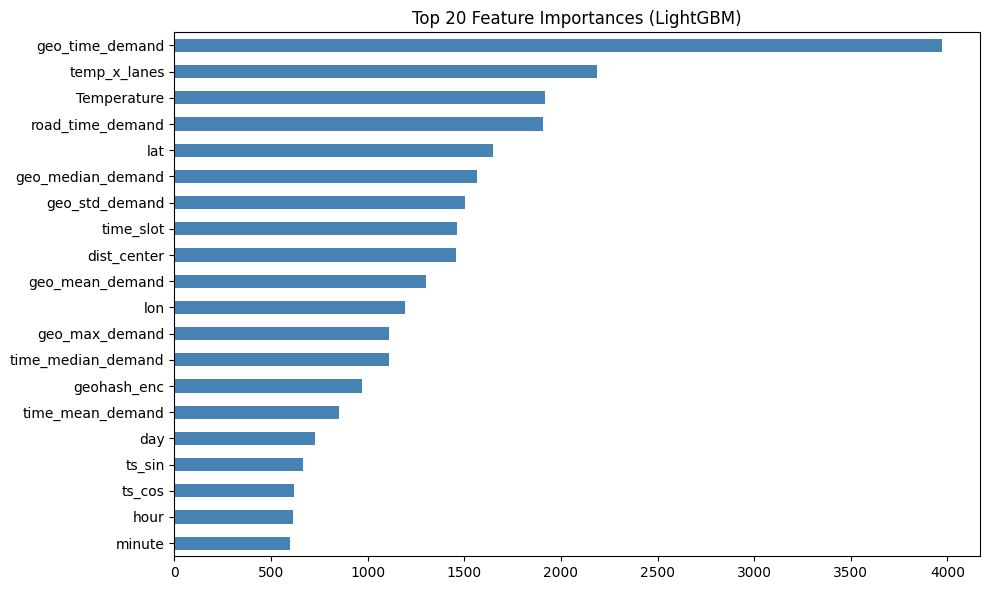

In [16]:
fi = pd.Series(lgb_model.feature_importances_, index=feature_cols)
top20 = fi.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances (LightGBM)')
plt.tight_layout()
plt.show()

## 9 · Actual vs Predicted

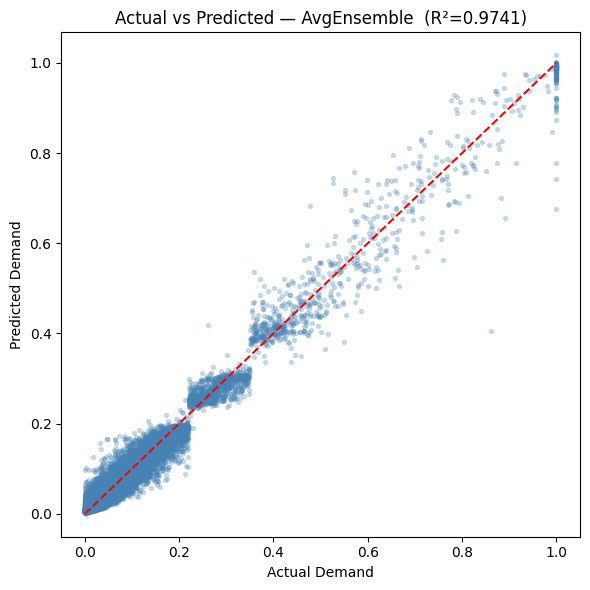

In [17]:
best_pred_val = results[best_name]['pred']

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_val, best_pred_val, alpha=0.25, s=8, color='steelblue')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5)
ax.set_xlabel('Actual Demand')
ax.set_ylabel('Predicted Demand')
ax.set_title(f'Actual vs Predicted — {best_name}  (R²={best_r2:.4f})')
plt.tight_layout()
plt.show()

## 10 · K-Fold Cross Validation
5-fold CV using LightGBM (fastest of the three). Flags instability when std > 0.02.

In [18]:
print('Running 5-fold CV (LightGBM)...')

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = []

for fold, (tr_idx, vl_idx) in enumerate(kf.split(X, y), 1):
    m = LGBMRegressor(
        n_estimators=500, max_depth=-1, num_leaves=63,
        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        min_child_samples=20, reg_alpha=0.1, reg_lambda=1.0,
        random_state=SEED, n_jobs=-1, verbose=-1
    )
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    preds = m.predict(X.iloc[vl_idx])
    s     = r2_score(y.iloc[vl_idx], preds)
    cv_scores.append(s)
    print(f'  Fold {fold}: R²={s:.4f}')

cv_mean = np.mean(cv_scores)
cv_std  = np.std(cv_scores)
print(f'\n5-Fold CV  mean R²={cv_mean:.4f}  std={cv_std:.4f}')

if cv_std > 0.02:
    print('WARNING: High variance across folds — model may be unstable!')
else:
    print('Stable across folds ✓')

Running 5-fold CV (LightGBM)...


  Fold 1: R²=0.9735


  Fold 2: R²=0.9756


  Fold 3: R²=0.9763


  Fold 4: R²=0.9728


  Fold 5: R²=0.9760

5-Fold CV  mean R²=0.9749  std=0.0014
Stable across folds ✓


## 11 · Train on Full Data & Generate Submission

In [19]:
print('Retraining on FULL train data...')

xgb_final = XGBRegressor(
    n_estimators=xgb_model.best_iteration, max_depth=7, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1
)
xgb_final.fit(X, y)

lgb_final = LGBMRegressor(
    n_estimators=lgb_model.best_iteration_, max_depth=-1, num_leaves=63,
    learning_rate=0.03, subsample=0.8, colsample_bytree=0.8,
    min_child_samples=20, reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_final.fit(X, y)

cat_final = CatBoostRegressor(
    iterations=cat_model.best_iteration_, depth=7, learning_rate=0.03,
    l2_leaf_reg=3, random_seed=SEED, verbose=0
)
cat_final.fit(X, y)

print('Retraining done ✓')

Retraining on FULL train data...


Retraining done ✓


In [20]:
xgb_test = xgb_final.predict(X_test)
lgb_test = lgb_final.predict(X_test)
cat_test = cat_final.predict(X_test)

if best_name == 'WeightedEnsemble':
    final_preds = weights[0]*xgb_test + weights[1]*lgb_test + weights[2]*cat_test
elif best_name == 'AvgEnsemble':
    final_preds = (xgb_test + lgb_test + cat_test) / 3
elif best_name == 'XGBoost':
    final_preds = xgb_test
elif best_name == 'LightGBM':
    final_preds = lgb_test
else:
    final_preds = cat_test

final_preds = np.clip(final_preds, 0.0, 1.0)

val_score = max(0, 100 * best_r2)
sub_path  = SUB_DIR / f'sayan_advanced_score{val_score:.1f}.csv'

pd.DataFrame({'Index': test['Index'], 'demand': final_preds}).to_csv(sub_path, index=False)

print(f'Submission saved → {sub_path}')
print(f'Predictions: min={final_preds.min():.4f}  max={final_preds.max():.4f}  mean={final_preds.mean():.4f}')

Submission saved → ../submissions/sayan_advanced_score97.4.csv
Predictions: min=0.0013  max=0.9975  mean=0.1271


## Final Summary

In [21]:
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
print(summary_df.to_string(index=False))
print()
print(f'5-Fold CV  mean={cv_mean:.4f}  std={cv_std:.4f}')
print(f'Chosen model : {best_name}')
print(f'Val score    : {val_score:.2f}')
print(f'Submission   : {sub_path}')
print()
print('Reason: highest validation R2 among all candidates.')
print('Ensemble smooths individual model errors for better generalisation.')

FINAL RESULTS SUMMARY
           Model  Val R2  Val Score
     AvgEnsemble  0.9741      97.41
WeightedEnsemble  0.9741      97.41
        LightGBM  0.9740      97.40
        CatBoost  0.9737      97.37
         XGBoost  0.9696      96.96

5-Fold CV  mean=0.9749  std=0.0014
Chosen model : AvgEnsemble
Val score    : 97.41
Submission   : ../submissions/sayan_advanced_score97.4.csv

Reason: highest validation R2 among all candidates.
Ensemble smooths individual model errors for better generalisation.
